# Static Dashboard — Energy Poverty Prediction

This dashboard communicates the key findings from the Energy Poverty Prediction project.
It uses World Bank data (1990–2023) across 218 countries to model and visualise
electricity access patterns, risk categories, and 2024–2027 forecasts.

## Key Takeaways
1. Global average electricity access rose from ~72% (1990) to ~90% (2023) but
   ~700M people remain without access — concentrated in Sub-Saharan Africa.
2. GDP per capita and renewable energy are the strongest predictors of electricity access.
3. RF Baseline classifier achieved **92.97% validation accuracy** predicting risk category.
4. RF Improved regressor achieved **R²=0.9178** predicting exact electricity access %.
5. **27 countries** are still projected to be in Severe energy poverty risk by 2027.

## Dashboard Structure
- **View 1**   — Global electricity access trend (1990–2023)
- **View 2**   — Risk category distribution over time
- **View 3**   — Electricity Access Progress (1990–2023)
- **View 4**   — Feature importance (what drives predictions)
- **View 5**   — Correlation with Electricity Access
- **View 6**   — Model performance comparison
- **View 7**   — Test set evaluation (actual vs predicted)
- **View 8**   — GDP vs electricity access relationship
- **View 9**   — 2024–2027 forecast
- **Widget A** — Country explorer (dropdown)
- **Widget B** — Year snapshot (slider)
- **Widget C** — Risk Transition Range (slider)

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS = True
    print("ipywidgets available — interactive widgets enabled")
except ImportError:
    WIDGETS = False
    print("ipywidgets not available — static fallbacks will be used")

# Load all data 
df          = pd.read_csv("data/processed/analysis_ready.csv")
test_df     = pd.read_csv("data/processed/test_predictions.csv")
feat_imp    = pd.read_csv("data/processed/feature_importance.csv")
forecast_df = pd.read_csv("data/processed/forecast_2024_2027.csv")

print(f"\nanalysis_ready    : {df.shape}")
print(f"test_predictions  : {test_df.shape}")
print(f"feature_importance: {feat_imp.shape}")
print(f"forecast_2024_2027: {forecast_df.shape}")

ipywidgets available — interactive widgets enabled

analysis_ready    : (7412, 15)
test_predictions  : (654, 7)
feature_importance: (20, 3)
forecast_2024_2027: (872, 16)



## View 1 — Global Electricity Access Trend (1990–2023)

How has global electricity access changed over 34 years?
 - Left chart shows the global average rising from ~72% (1990) to ~90% (2023)
 - Right chart shows the distribution across countries in the most recent year
 - The bimodal shape on the right reveals deep inequality — many countries near 100%, many still stuck below 50%

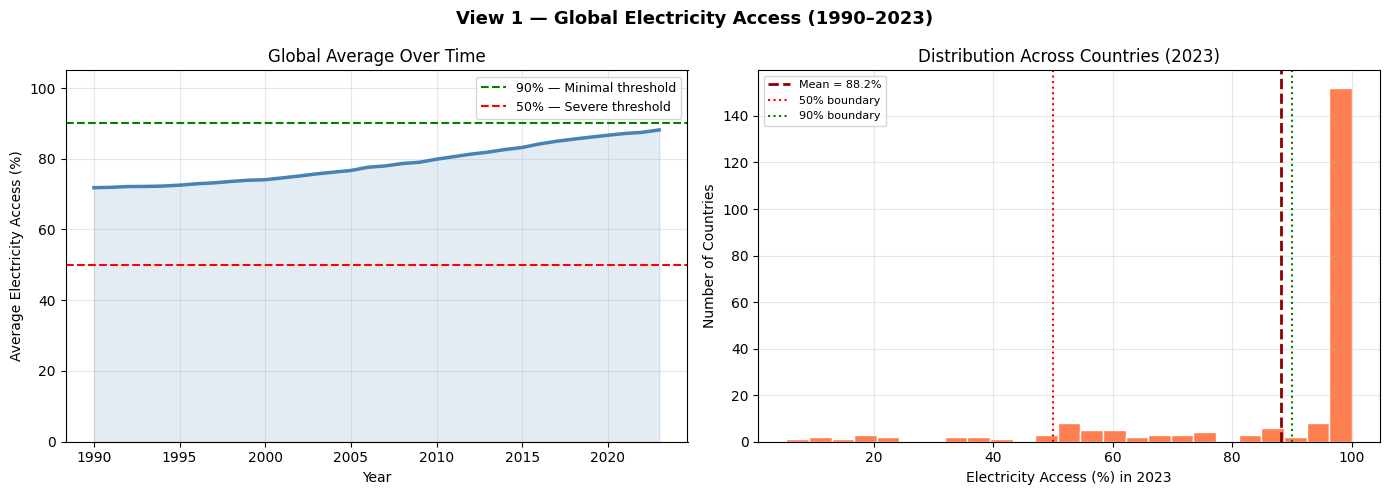

In [2]:
# View 1: Global Electricity Access (1990–2023) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("View 1 — Global Electricity Access (1990–2023)",
             fontsize=13, fontweight='bold')

# Left: global average over time
global_avg = df.groupby('year')['electricity_access'].mean()
axes[0].plot(global_avg.index, global_avg.values,
             color='steelblue', linewidth=2.5)
axes[0].fill_between(global_avg.index, global_avg.values,
                     alpha=0.15, color='steelblue')
axes[0].axhline(90, color='green', linestyle='--',
                linewidth=1.5, label='90% — Minimal threshold')
axes[0].axhline(50, color='red', linestyle='--',
                linewidth=1.5, label='50% — Severe threshold')
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Electricity Access (%)")
axes[0].set_title("Global Average Over Time")
axes[0].set_ylim(0, 105)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: distribution in most recent year
latest    = int(df['year'].max())
latest_df = df[df['year'] == latest]['electricity_access'].dropna()
axes[1].hist(latest_df, bins=25, color='coral', edgecolor='white')
axes[1].axvline(latest_df.mean(), color='darkred', linestyle='--',
                linewidth=2, label=f"Mean = {latest_df.mean():.1f}%")
axes[1].axvline(50, color='red', linestyle=':',
                linewidth=1.5, label='50% boundary')
axes[1].axvline(90, color='green', linestyle=':',
                linewidth=1.5, label='90% boundary')
axes[1].set_xlabel(f"Electricity Access (%) in {latest}")
axes[1].set_ylabel("Number of Countries")
axes[1].set_title(f"Distribution Across Countries ({latest})")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## View 2 — Risk Category Distribution (1990–2023)

How are countries distributed across risk categories and how has this changed over time?

- **Left:** Overall count of country-year rows in each risk category across the full dataset.
  Minimal dominates at 4,614 rows — most countries have had good access for many years.
- **Right:** How the number of countries in each category changed year by year.
  Severe (red) has declined steadily since 1990 — global progress is real.
  The dashed lines mark the train/validation/test split boundaries.

**Key insight:** The sharp drop in Severe countries after 2010 reflects major
electrification pushes in South Asia and Sub-Saharan Africa.

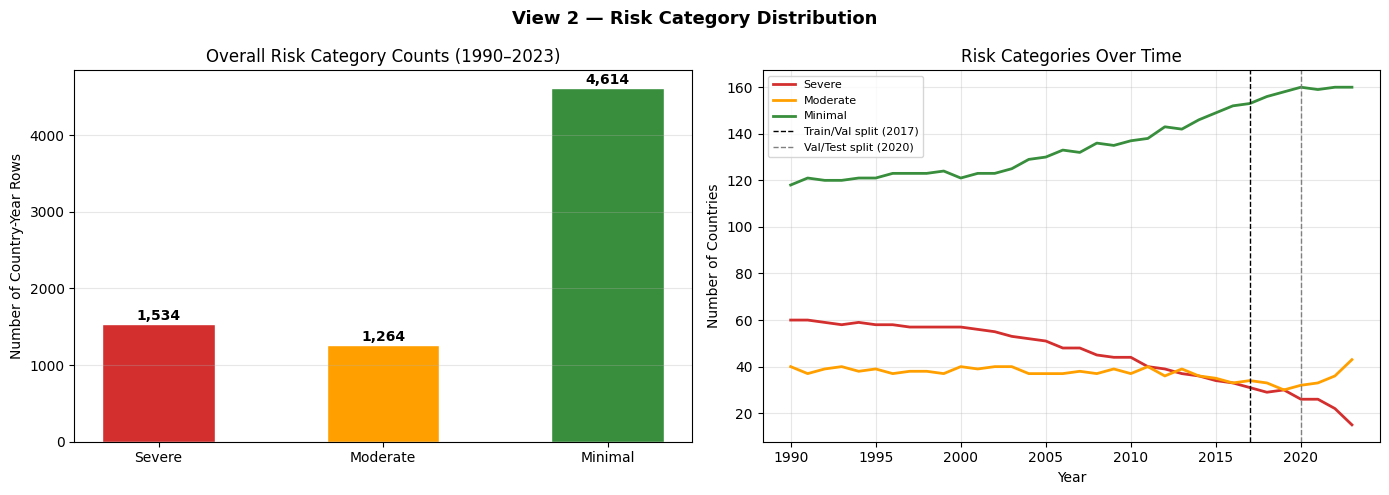

In [3]:
# View 2: Risk Category Distribution — Bar Charts + Line Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("View 2 — Risk Category Distribution",
             fontsize=13, fontweight='bold')

order  = ['Severe', 'Moderate', 'Minimal']
colors = ['#D32F2F', '#FFA000', '#388E3C']

# Left: overall counts
counts = df['risk_category'].value_counts()
vals   = [counts.get(c, 0) for c in order]
bars   = axes[0].bar(order, vals, color=colors,
                     edgecolor='white', width=0.5)
axes[0].set_title("Overall Risk Category Counts (1990–2023)")
axes[0].set_ylabel("Number of Country-Year Rows")
axes[0].grid(True, axis='y', alpha=0.3)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{v:,}', ha='center', fontweight='bold')

# Right: trend over time with split boundaries
risk_by_year = (df.groupby(['year', 'risk_category'])
                .size().unstack(fill_value=0))
for cat, col in zip(order, colors):
    if cat in risk_by_year.columns:
        axes[1].plot(risk_by_year.index, risk_by_year[cat],
                     label=cat, color=col, linewidth=2)

axes[1].axvline(2017, color='black', linestyle='--',
                linewidth=1, label='Train/Val split (2017)')
axes[1].axvline(2020, color='grey', linestyle='--',
                linewidth=1, label='Val/Test split (2020)')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Countries")
axes[1].set_title("Risk Categories Over Time")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## View 3 — Electricity Access Progress (1990–2023)

Which countries improved the most and which are still the worst off?
 - Left chart shows the top 10 most improved countries by percentage point gain
 - Right chart shows the 15 countries with the lowest electricity access today
 - Dark red bars = below 30% access — the most critical cases requiring intervention

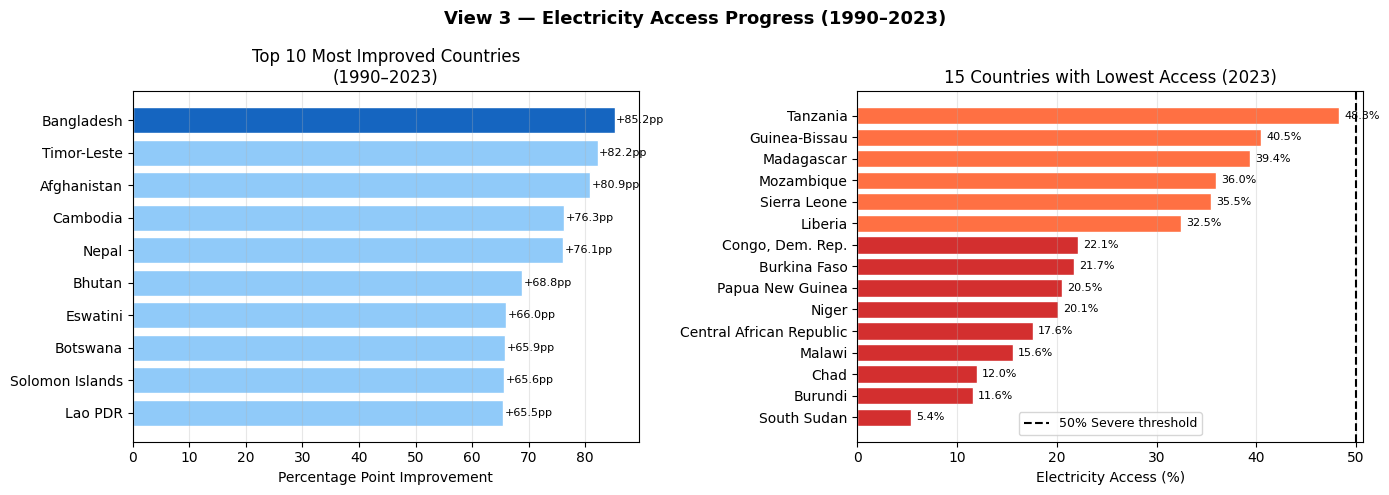

In [4]:
# View 3: Progress & Challenges — Bar Charts

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("View 3 — Electricity Access Progress (1990–2023)",
             fontsize=13, fontweight='bold')

# Left: top 10 most improved countries
first_year = df.groupby('country')['electricity_access'].first()
last_year  = df.groupby('country')['electricity_access'].last()
improvement = (last_year - first_year).sort_values(ascending=False).head(10)

colors_imp = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(improvement))]
axes[0].barh(improvement.index[::-1], improvement.values[::-1],
             color=colors_imp[::-1], edgecolor='white')
axes[0].set_xlabel("Percentage Point Improvement")
axes[0].set_title("Top 10 Most Improved Countries\n(1990–2023)")
axes[0].grid(True, axis='x', alpha=0.3)
for i, (country, val) in enumerate(zip(improvement.index[::-1], improvement.values[::-1])):
    axes[0].text(val + 0.3, i, f'+{val:.1f}pp', va='center', fontsize=8)

# Right: countries still below 50% in most recent year
latest_year = int(df['year'].max())
severe_now  = (df[df['year'] == latest_year]
               .sort_values('electricity_access')
               .head(15)[['country', 'electricity_access']])
colors_sev  = ['#D32F2F' if v < 30 else '#FF7043'
               for v in severe_now['electricity_access']]
axes[1].barh(severe_now['country'], severe_now['electricity_access'],
             color=colors_sev, edgecolor='white')
axes[1].axvline(50, color='black', linestyle='--',
                linewidth=1.5, label='50% Severe threshold')
axes[1].set_xlabel("Electricity Access (%)")
axes[1].set_title(f"15 Countries with Lowest Access ({latest_year})")
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='x', alpha=0.3)
for i, (_, row) in enumerate(severe_now.iterrows()):
    axes[1].text(row['electricity_access'] + 0.5, i,
                 f"{row['electricity_access']:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()

## View 4 — Feature Importance — Best Models

Which features contributed most to each model's predictions?
The **dark blue bar** is the single most important feature in each model.

- **Left (Regressor):** `renewable_energy_percent` dominates at 0.445 — a country's
  energy mix is the strongest signal for predicting exact electricity access %.
  `gdp_per_capita` is second at 0.231 — economic wealth drives infrastructure investment.

- **Right (Classifier):** More balanced distribution — `renewable_energy_percent` (0.227)
  and `gdp_per_capita` (0.186) lead, but population and urbanisation features also
  contribute meaningfully to classifying risk category.

**Key insight:** Both models agree that energy mix and economic output are the
primary drivers of electricity access — policy interventions targeting renewable
investment and economic development will have the most impact on reducing energy poverty.

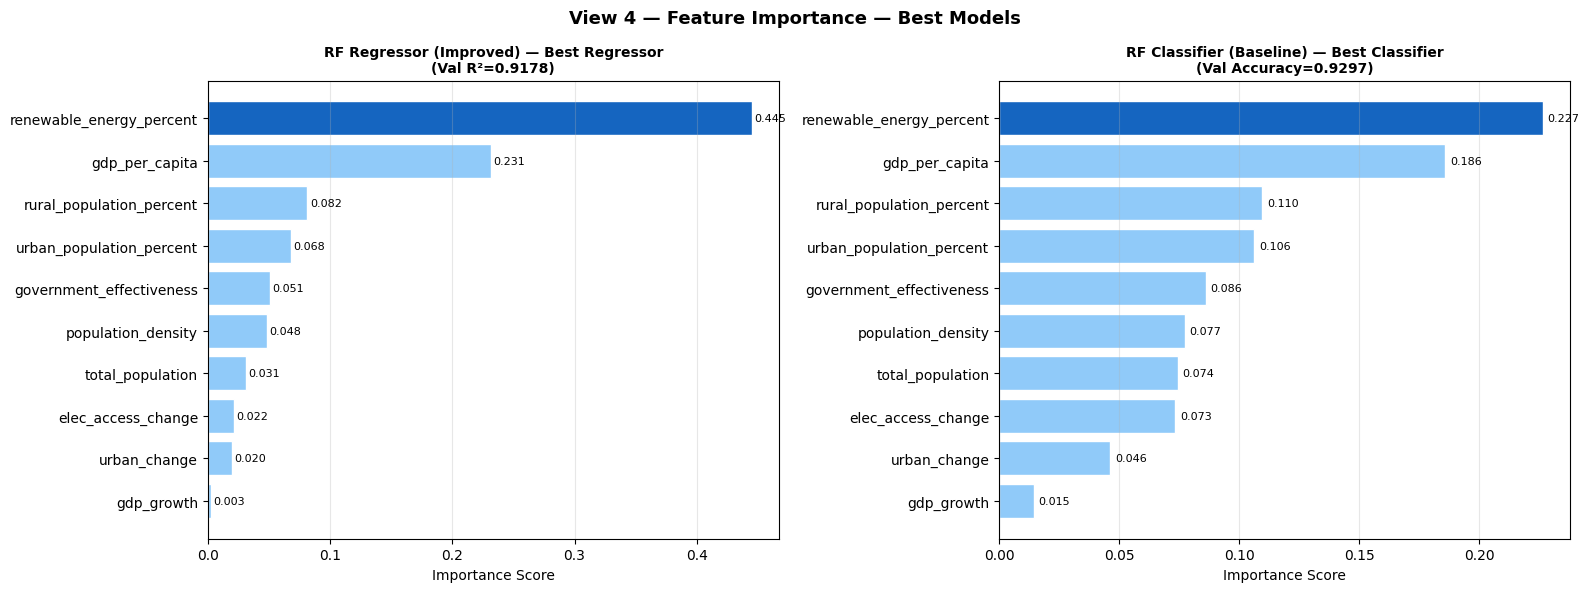

In [5]:
# View 4: Feature Importance — Bar Charts

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("View 4 — Feature Importance — Best Models",
             fontsize=13, fontweight='bold')

cls_imp = feat_imp[feat_imp['model'] == 'classifier'].sort_values('importance')
reg_imp = feat_imp[feat_imp['model'] == 'regressor'].sort_values('importance')

for ax, imp, title in zip(
    axes,
    [reg_imp, cls_imp],
    ['RF Regressor (Improved) — Best Regressor\n(Val R²=0.9178)',
     'RF Classifier (Baseline) — Best Classifier\n(Val Accuracy=0.9297)']
):
    colors_bar = ['#1565C0' if v == imp['importance'].max()
                  else '#90CAF9' for v in imp['importance']]
    ax.barh(imp['feature'], imp['importance'],
            color=colors_bar, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Importance Score')
    ax.grid(True, axis='x', alpha=0.3)
    for i, (feat, val) in enumerate(zip(imp['feature'], imp['importance'])):
        ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## View 5 — Correlation with Electricity Access

Pearson correlation of each feature against the target variable `electricity_access`.

- **Blue bars** = positive correlation — higher value means higher electricity access
- **Red bars** = negative correlation — higher value means lower electricity access

**Key findings:**
- `rural_population_percent` is the strongest negative driver — more rural population
  means less electricity access, reflecting the high cost of extending grids to
  remote areas
- `gdp_per_capita` and `renewable_energy_percent` are the strongest positive drivers —
  confirming that economic wealth and clean energy investment go hand in hand with
  electrification
- `government_effectiveness` has a moderate positive correlation — stronger institutions
  are better at delivering infrastructure to their populations
- `gdp_growth` and `urban_change` show near-zero correlation — annual change rates
  matter less than the underlying structural levels

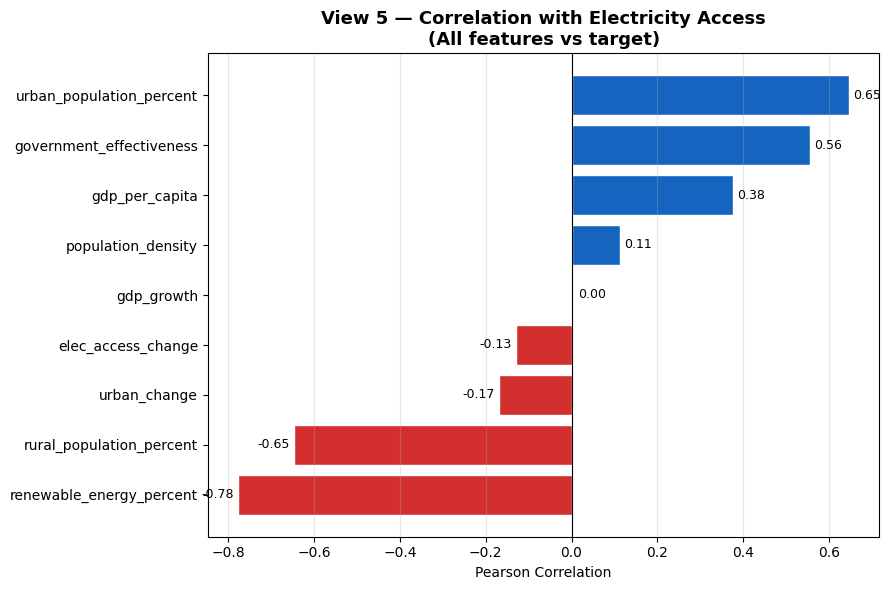

In [6]:
# View 5 — Correlation with Electricity Access
numeric_cols = ['electricity_access', 'gdp_per_capita', 'urban_population_percent',
                'rural_population_percent', 'renewable_energy_percent',
                'government_effectiveness', 'population_density',
                'elec_access_change', 'gdp_growth', 'urban_change']

corr = (df[numeric_cols].corr()['electricity_access']
        .drop('electricity_access')
        .sort_values())

colors_corr = ['#D32F2F' if v < 0 else '#1565C0' for v in corr.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("View 5 — Correlation with Electricity Access\n(All features vs target)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Pearson Correlation")
ax.grid(True, axis='x', alpha=0.3)

for i, (feat, val) in enumerate(zip(corr.index, corr.values)):
    offset = 0.01 if val >= 0 else -0.01
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, i, f'{val:.2f}', va='center', fontsize=9, ha=ha)

plt.tight_layout()
plt.show()

## View 6 — Model Performance Comparison

Comparing all 4 models on the validation set (2018–2020).
- Dark blue bar = best performing model in each task
- RF Baseline surprisingly outperforms tuned models on classification — simpler
  models generalise better when the class distribution shifts over time
- RF Improved wins on regression with R²=0.9178

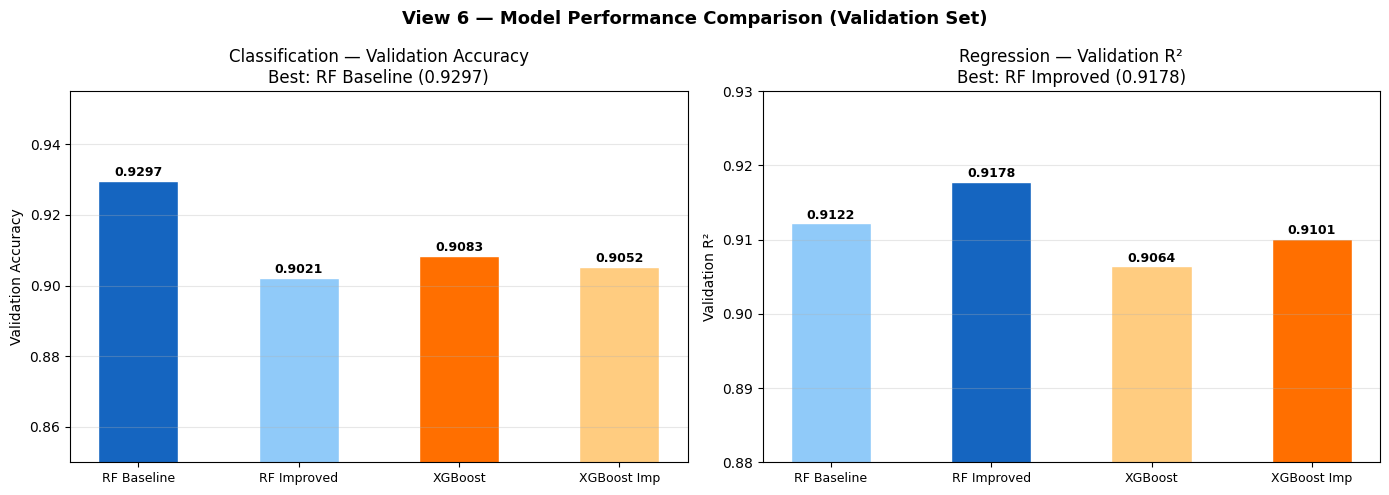

In [7]:
# View 6: Model Performance Comparison — Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("View 6 — Model Performance Comparison (Validation Set)",
             fontsize=13, fontweight='bold')

# Classification
cls_models = ['RF Baseline', 'RF Improved', 'XGBoost', 'XGBoost Imp']
cls_scores = [0.9297, 0.9021, 0.9083, 0.9052]
cls_colors = ['#1565C0', '#90CAF9', '#FF6F00', '#FFCC80']

bars = axes[0].bar(cls_models, cls_scores,
                   color=cls_colors, edgecolor='white', width=0.5)
axes[0].set_ylim(0.85, 0.955)
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("Classification — Validation Accuracy\nBest: RF Baseline (0.9297)")
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].tick_params(axis='x', labelsize=9)
for bar, val in zip(bars, cls_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontweight='bold', fontsize=9)

# Regression
reg_models = ['RF Baseline', 'RF Improved', 'XGBoost', 'XGBoost Imp']
reg_scores = [0.9122, 0.9178, 0.9064, 0.9101]
reg_colors = ['#90CAF9', '#1565C0', '#FFCC80', '#FF6F00']

bars2 = axes[1].bar(reg_models, reg_scores,
                    color=reg_colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0.88, 0.930)
axes[1].set_ylabel("Validation R²")
axes[1].set_title("Regression — Validation R²\nBest: RF Improved (0.9178)")
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].tick_params(axis='x', labelsize=9)
for bar, val in zip(bars2, reg_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## View 7 — Test Set Evaluation (2021–2023)

Final honest evaluation on data the model never saw during training or tuning.
- Left: actual vs predicted electricity access — dots close to the diagonal = accurate predictions
- Right: confusion matrix — Moderate class is hardest to predict (transition zone)
- Test accuracy drops from 92.97% (validation) to 87.77% — expected due to temporal shift

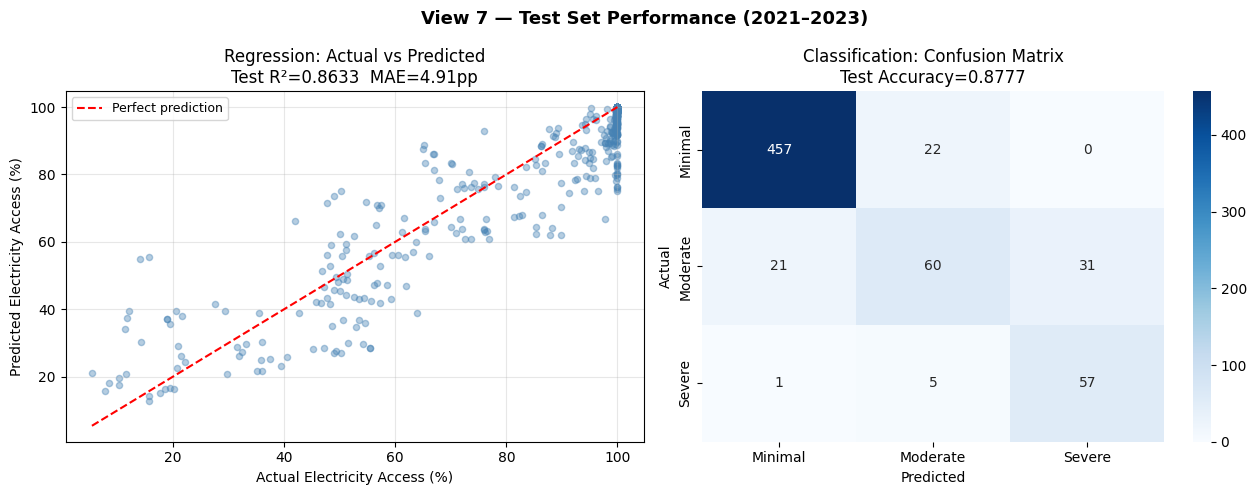

In [8]:
# View 7: Test Set Performance — Scatter + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("View 7 — Test Set Performance (2021–2023)",
             fontsize=13, fontweight='bold')

# Left: actual vs predicted scatter
axes[0].scatter(test_df['electricity_access'],
                test_df['pred_electricity_access'],
                alpha=0.4, s=20, color='steelblue')
lo = test_df['electricity_access'].min()
hi = test_df['electricity_access'].max()
axes[0].plot([lo, hi], [lo, hi], 'r--',
             linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel("Actual Electricity Access (%)")
axes[0].set_ylabel("Predicted Electricity Access (%)")
axes[0].set_title("Regression: Actual vs Predicted\nTest R²=0.8633  MAE=4.91pp")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: confusion matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
le_dash = LabelEncoder()
le_dash.fit(['Minimal', 'Moderate', 'Severe'])
y_true = le_dash.transform(test_df['risk_category'])
y_pred = le_dash.transform(test_df['pred_risk_category'])
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_dash.classes_,
            yticklabels=le_dash.classes_, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Classification: Confusion Matrix\nTest Accuracy=0.8777")

plt.tight_layout()
plt.show()

## View 8 — GDP vs Electricity Access

The relationship between economic development and electricity access across all years.
- Each dot = one country in that year
- Clear positive relationship — richer countries have higher electricity access
- The gap between 1995 and 2023 shows how access improved as GDP grew
- Countries above the green line (90%) are Minimal risk — mostly high-income nations

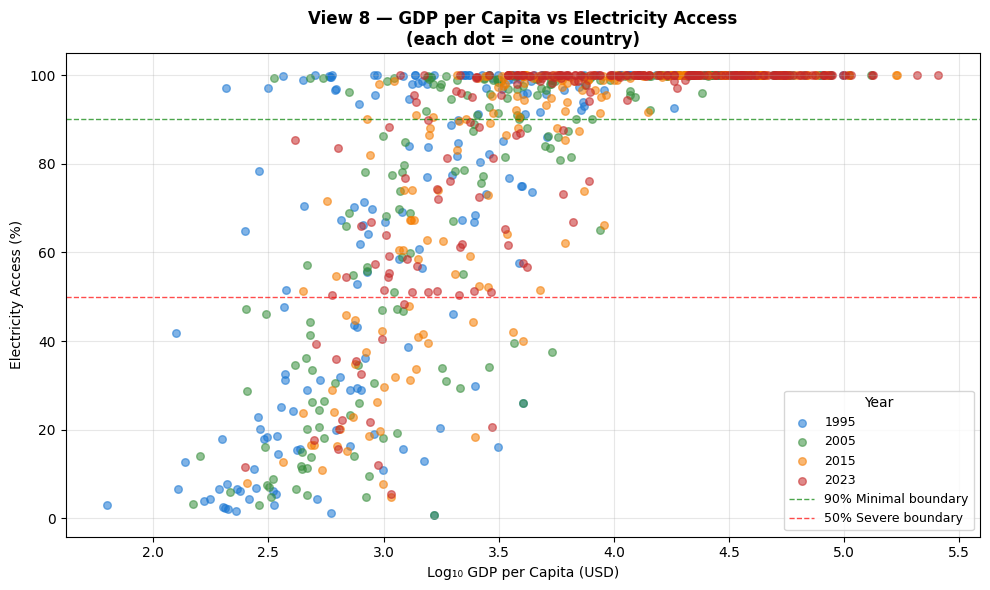

In [9]:
# View 8: GDP per Capita vs Electricity Access — Scatter Plot with Boundaries
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("View 8 — GDP per Capita vs Electricity Access\n(each dot = one country)",
             fontsize=12, fontweight='bold')

years_to_show = [1995, 2005, 2015, 2023]
palette       = ['#1976D2', '#388E3C', '#F57C00', '#C62828']

for yr, col in zip(years_to_show, palette):
    sub = df[df['year'] == yr].dropna(
        subset=['gdp_per_capita', 'electricity_access'])
    ax.scatter(np.log10(sub['gdp_per_capita'] + 1),
               sub['electricity_access'],
               alpha=0.55, s=30, color=col, label=str(int(yr)))

ax.axhline(90, color='green', linestyle='--',
           linewidth=1, alpha=0.7, label='90% Minimal boundary')
ax.axhline(50, color='red', linestyle='--',
           linewidth=1, alpha=0.7, label='50% Severe boundary')
ax.set_xlabel("Log₁₀ GDP per Capita (USD)")
ax.set_ylabel("Electricity Access (%)")
ax.legend(title="Year", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## View 9 — 2024–2027 Energy Poverty Forecast

Applying the best trained models to project electricity access and risk categories
for 2024–2027 across all 218 countries.

| Year | Avg Access | Severe | Moderate | Minimal |
|------|-----------|--------|----------|---------|
| 2024 | 85.8%     | 30     | 28       | 160     |
| 2025 | 85.9%     | 30     | 27       | 161     |
| 2026 | 86.1%     | 28     | 29       | 161     |
| 2027 | 86.3%     | 27     | 30       | 161     |

**27 countries** remain in Severe risk by 2027 — almost entirely in Sub-Saharan Africa.

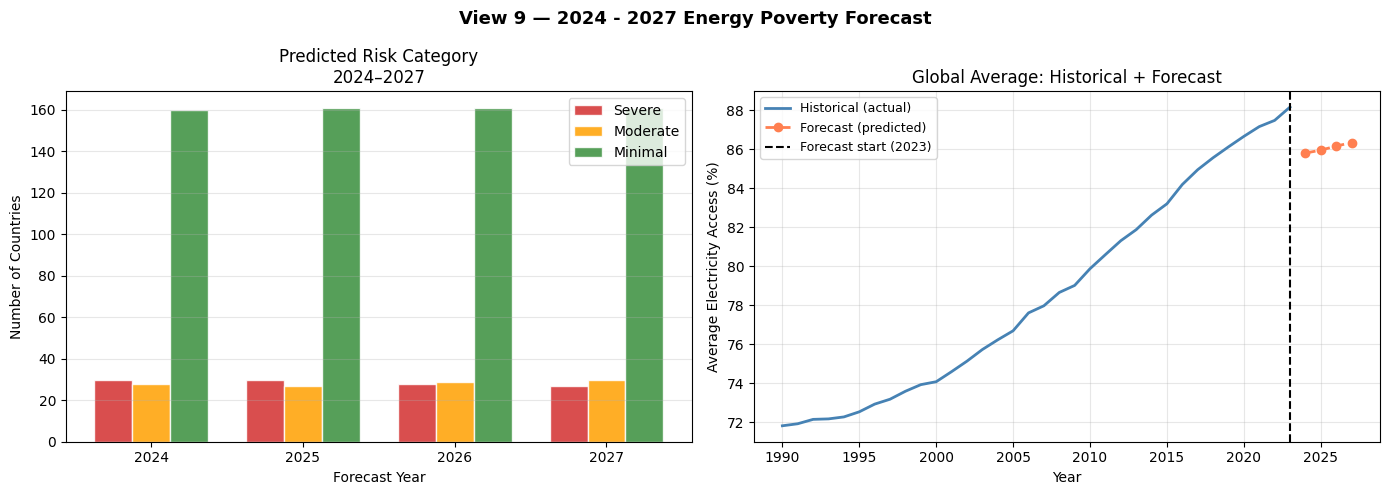

In [10]:
# View 9: 2024 - 2027 Energy Poverty Forecast — Bar Charts + Line Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("View 9 — 2024 - 2027 Energy Poverty Forecast",
             fontsize=13, fontweight='bold')

# Left: predicted risk distribution by year
order  = ['Severe', 'Moderate', 'Minimal']
colors = ['#D32F2F', '#FFA000', '#388E3C']
years  = [2024, 2025, 2026, 2027]
x      = np.arange(len(years))
width  = 0.25

for i, (cat, col) in enumerate(zip(order, colors)):
    vals = [forecast_df[forecast_df['year'] == yr]['pred_risk_category']
            .value_counts().get(cat, 0) for yr in years]
    axes[0].bar(x + i * width, vals, width,
                label=cat, color=col,
                edgecolor='white', alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(years)
axes[0].set_xlabel("Forecast Year")
axes[0].set_ylabel("Number of Countries")
axes[0].set_title("Predicted Risk Category\n2024–2027")
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# Right: historical + forecast average
hist_avg = df.groupby('year')['electricity_access'].mean()
fore_avg = forecast_df.groupby('year')['pred_electricity_access'].mean()

axes[1].plot(hist_avg.index, hist_avg.values,
             color='steelblue', linewidth=2, label='Historical (actual)')
axes[1].plot(fore_avg.index, fore_avg.values,
             color='coral', linewidth=2, linestyle='--',
             marker='o', label='Forecast (predicted)')
axes[1].axvline(2023, color='black', linestyle='--',
                linewidth=1.5, label='Forecast start (2023)')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average Electricity Access (%)")
axes[1].set_title("Global Average: Historical + Forecast")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Interactive Widgets

Use the widgets below to explore the data interactively.
- **Widget A** — Select any country to see its full trajectory and model predictions
- **Widget B** — Drag the year slider to explore the global snapshot for any year
- **Widget C** — Select multiple regions to compare electricity access trends

## Widget A — Country Explorer

Select any country from the dropdown to explore its full trajectory.
- **Blue line** = actual historical electricity access (1990–2023)
- **Coral dots** = model predictions on the test set (2021–2023)
- **Purple dots** = forecast (2024–2027)
- The green dashed line marks 90% (Minimal threshold)
- The red dashed line marks 50% (Severe threshold)

In [11]:
if WIDGETS:
    country_list = sorted(df['country'].unique().tolist())

    dd    = widgets.Dropdown(
        options=country_list, value='India',
        description='Country:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='300px')
    )
    out_a = widgets.Output()

    def plot_country(change):
        with out_a:
            clear_output(wait=True)
            c        = dd.value
            sub      = df[df['country'] == c].sort_values('year')
            test_sub = test_df[test_df['country'] == c].sort_values('year')
            fore_sub = forecast_df[forecast_df['country'] == c].sort_values('year')

            fig, axes = plt.subplots(1, 2, figsize=(13, 4))
            fig.suptitle(f"{c} — Electricity Access & GDP per Capita",
                         fontsize=12, fontweight='bold')

            # Left: historical + test predictions + forecast
            axes[0].plot(sub['year'], sub['electricity_access'],
                         'o-', color='steelblue', label='Actual', linewidth=2)
            if len(test_sub) > 0:
                axes[0].plot(test_sub['year'],
                             test_sub['pred_electricity_access'],
                             's--', color='coral',
                             label='Predicted (test 2021–2023)', linewidth=2)
            if len(fore_sub) > 0:
                axes[0].plot(fore_sub['year'],
                             fore_sub['pred_electricity_access'],
                             '^--', color='purple',
                             label='Forecast (2024–2027)', linewidth=2)
            axes[0].axhline(90, color='green', linestyle='--',
                            linewidth=1, alpha=0.7)
            axes[0].axhline(50, color='red', linestyle='--',
                            linewidth=1, alpha=0.7)
            axes[0].set_xlabel("Year")
            axes[0].set_ylabel("Electricity Access (%)")
            axes[0].set_title("Historical + Predictions + Forecast")
            axes[0].legend(fontsize=8)
            axes[0].grid(True, alpha=0.3)

            # Right: GDP trend
            axes[1].plot(sub['year'], sub['gdp_per_capita'] / 1000,
                         'o-', color='#388E3C', linewidth=2)
            axes[1].set_xlabel("Year")
            axes[1].set_ylabel("GDP per Capita (USD thousands)")
            axes[1].set_title("GDP per Capita Trend")
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

    dd.observe(plot_country, names='value')
    display(widgets.VBox([
        widgets.HTML(
            "<b>Widget A — Country Explorer</b><br>"
            "Blue = actual history | Coral = model test predictions (2021–2023) | "
            "Purple = forecast (2024 - 2027)"
        ),
        dd,
        out_a
    ]))
    plot_country(None)

else:
    for c in ['India', 'Nigeria', 'Brazil']:
        sub = df[df['country'] == c].sort_values('year')
        plt.plot(sub['year'], sub['electricity_access'], 'o-', label=c)
    plt.title("Electricity Access — India / Nigeria / Brazil")
    plt.ylabel("Electricity Access (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Widget B — Global Year Snapshot

Drag the slider to explore any year from 1990 to 2023.
- **X axis** = Log GDP per capita — the #2 most important feature in both models
- **Y axis** = Electricity access %
- **Colour** = Renewable energy % — the #1 most important feature in both models
- Green = high renewable energy share | Red = low renewable energy share

This chart puts the two strongest predictors from feature importance together
in one view. Countries in the top-right with green colour have high GDP, high
renewable energy, and high electricity access — confirming what the models learned.

In [12]:
if WIDGETS:
    slider = widgets.IntSlider(
        value=2015,
        min=int(df['year'].min()),
        max=int(df['year'].max()),
        step=1,
        description='Year:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )
    out_b = widgets.Output()

    def plot_year(change):
        with out_b:
            clear_output(wait=True)
            yr  = slider.value
            sub = df[df['year'] == yr].dropna(
                subset=['gdp_per_capita', 'electricity_access',
                        'renewable_energy_percent'])

            fig, ax = plt.subplots(figsize=(9, 5))
            sc = ax.scatter(
                np.log10(sub['gdp_per_capita'] + 1),
                sub['electricity_access'],
                c=sub['renewable_energy_percent'],
                cmap='RdYlGn', alpha=0.75, s=50,
                vmin=0, vmax=100
            )
            plt.colorbar(sc, ax=ax, label='Renewable Energy %')
            ax.axhline(90, color='green', linestyle='--',
                       linewidth=1.5, alpha=0.7, label='90% Minimal')
            ax.axhline(50, color='red', linestyle='--',
                       linewidth=1.5, alpha=0.7, label='50% Severe')
            ax.set_xlabel("Log₁₀ GDP per Capita (USD)")
            ax.set_ylabel("Electricity Access (%)")
            ax.set_title(
                f"GDP vs Electricity Access ({yr})\n"
                f"Colour = Renewable Energy % | {len(sub)} countries shown"
            )
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    slider.observe(plot_year, names='value')
    display(widgets.VBox([
        widgets.HTML(
            "<b>Widget B — Global Year Snapshot</b><br>"
            "Drag the slider to explore any year from 1990–2023. "
            "X axis = GDP (economic development). "
            "Colour = Renewable Energy % — the two strongest predictors "
            "from feature importance both visible in one chart."
        ),
        slider,
        out_b
    ]))
    plot_year(None)

else:
    yr  = 2015
    sub = df[df['year'] == yr].dropna(
        subset=['gdp_per_capita', 'electricity_access',
                'renewable_energy_percent'])
    fig, ax = plt.subplots(figsize=(9, 5))
    sc = ax.scatter(np.log10(sub['gdp_per_capita'] + 1),
                    sub['electricity_access'],
                    c=sub['renewable_energy_percent'],
                    cmap='RdYlGn', alpha=0.75, s=50)
    plt.colorbar(sc, ax=ax, label='Renewable Energy %')
    ax.set_title(f"GDP vs Electricity Access ({yr}) | Colour = Renewable Energy %")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Widget C — Risk Category Transition Explorer

Drag the range slider to compare any two years and see how countries moved
between risk categories.

- **Transition matrix** — rows = starting category, columns = ending category.
  Diagonal = stayed the same. Off-diagonal = moved to a different category.
- **Right panel** — lists which Severe countries improved and which remain stuck.

**Key insight:** Try 1990→2023 to see the full 34-year picture.
Most Severe countries in 1990 have moved to Moderate or Minimal by 2023,
but a stubborn core remain Severe — these are the same 27 countries
the forecast predicts will still be Severe in 2027.

In [13]:
# Widget C: Country Risk Trajectory 
if WIDGETS:
    year_range = widgets.IntRangeSlider(
        value=[2000, 2023],
        min=1990,
        max=2023,
        step=1,
        description='Year Range:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='450px')
    )
    out_c = widgets.Output()

    def plot_transition(change):
        with out_c:
            clear_output(wait=True)
            start_yr, end_yr = year_range.value

            start = df[df['year'] == start_yr][['country', 'risk_category']].rename(
                columns={'risk_category': 'start_category'})
            end   = df[df['year'] == end_yr][['country', 'risk_category']].rename(
                columns={'risk_category': 'end_category'})

            merged = start.merge(end, on='country').dropna()

            order   = ['Severe', 'Moderate', 'Minimal']
            colors  = ['#D32F2F', '#FFA000', '#388E3C']
            fig, axes = plt.subplots(1, 2, figsize=(13, 5))
            fig.suptitle(
                f"Risk Category: {start_yr} → {end_yr}",
                fontsize=12, fontweight='bold'
            )

            # Left: transition heatmap
            transition = pd.crosstab(
                merged['start_category'],
                merged['end_category']
            ).reindex(index=order, columns=order, fill_value=0)

            sns.heatmap(transition, annot=True, fmt='d',
                        cmap='Blues', ax=axes[0],
                        xticklabels=order, yticklabels=order)
            axes[0].set_xlabel(f"Category in {end_yr}")
            axes[0].set_ylabel(f"Category in {start_yr}")
            axes[0].set_title("Transition Matrix\n(rows=start, cols=end)")

            # Right: who improved and who didn't
            improved  = merged[
                (merged['start_category'] == 'Severe') &
                (merged['end_category'] != 'Severe')
            ]['country'].tolist()
            no_change = merged[
                (merged['start_category'] == 'Severe') &
                (merged['end_category'] == 'Severe')
            ]['country'].tolist()

            axes[1].axis('off')
            axes[1].set_title(
                f"Severe in {start_yr} — What happened by {end_yr}?",
                fontweight='bold'
            )

            text  = f"Improved out of Severe ({len(improved)}):\n"
            text += "\n".join(f"  • {c}" for c in sorted(improved)[:15])
            if len(improved) > 15:
                text += f"\n  ... and {len(improved)-15} more"
            text += f"\n\nStill Severe ({len(no_change)}):\n"
            text += "\n".join(f"  • {c}" for c in sorted(no_change)[:15])

            axes[1].text(0.02, 0.95, text,
                         transform=axes[1].transAxes,
                         fontsize=8, va='top', family='monospace',
                         bbox=dict(boxstyle='round', facecolor='#F5F5F5',
                                   alpha=0.8))

            plt.tight_layout()
            plt.show()

    year_range.observe(plot_transition, names='value')
    display(widgets.VBox([
        widgets.HTML(
            "<b>Widget C — Risk Category Transition Explorer</b><br>"
            "Drag the range slider to compare any two years. "
            "The transition matrix shows how countries moved between risk categories. "
            "The right panel lists which Severe countries improved and which did not."
        ),
        year_range,
        out_c
    ]))
    plot_transition(None)

else:
    start_yr, end_yr = 2000, 2023
    start = df[df['year'] == start_yr][['country','risk_category']].rename(
        columns={'risk_category': 'start_category'})
    end   = df[df['year'] == end_yr][['country','risk_category']].rename(
        columns={'risk_category': 'end_category'})
    merged = start.merge(end, on='country').dropna()
    order  = ['Severe', 'Moderate', 'Minimal']
    transition = pd.crosstab(
        merged['start_category'],
        merged['end_category']
    ).reindex(index=order, columns=order, fill_value=0)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(transition, annot=True, fmt='d', cmap='Blues',
                xticklabels=order, yticklabels=order, ax=ax)
    ax.set_xlabel(f"Category in {end_yr}")
    ax.set_ylabel(f"Category in {start_yr}")
    ax.set_title(f"Risk Transition {start_yr}→{end_yr}")
    plt.tight_layout()
    plt.show()